In [1]:
import numpy  as np
import cv2
import matplotlib.pyplot as plt

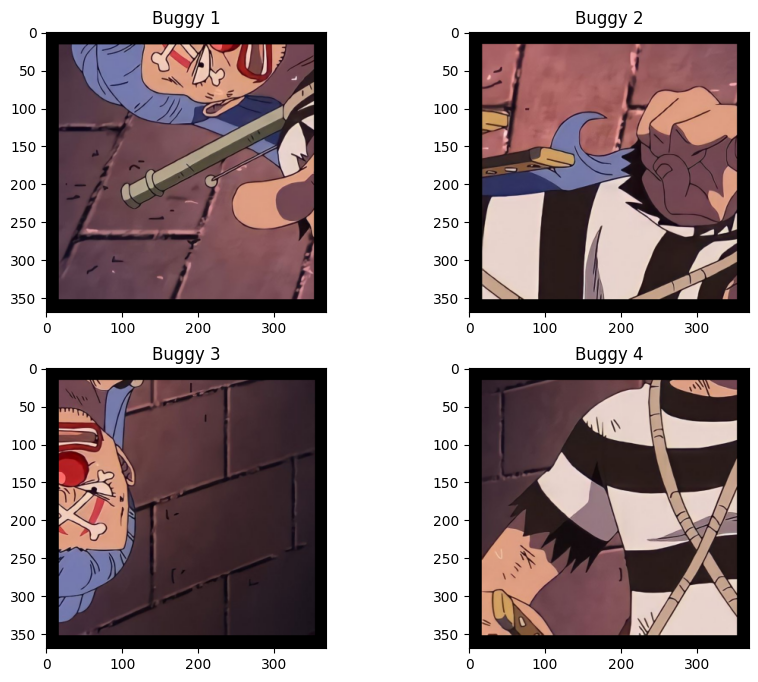

In [2]:
citra1 = cv2.imread("assets/buggy1.png")
citra2 = cv2.imread("assets/buggy2.png")
citra3 = cv2.imread("assets/buggy3.png")
citra4 = cv2.imread("assets/buggy4.png")

#RGB
citra1_rgb = cv2.cvtColor(citra1, cv2.COLOR_BGR2RGB)
citra2_rgb = cv2.cvtColor(citra2, cv2.COLOR_BGR2RGB)
citra3_rgb = cv2.cvtColor(citra3, cv2.COLOR_BGR2RGB)
citra4_rgb = cv2.cvtColor(citra4, cv2.COLOR_BGR2RGB)                       

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(citra1_rgb)
plt.title('Buggy 1')

plt.subplot(2, 2, 2)
plt.imshow(citra2_rgb)
plt.title('Buggy 2')

plt.subplot(2, 2, 3)
plt.imshow(citra3_rgb)
plt.title('Buggy 3')

plt.subplot(2, 2, 4)
plt.imshow(citra4_rgb)
plt.title('Buggy 4')

plt.show()

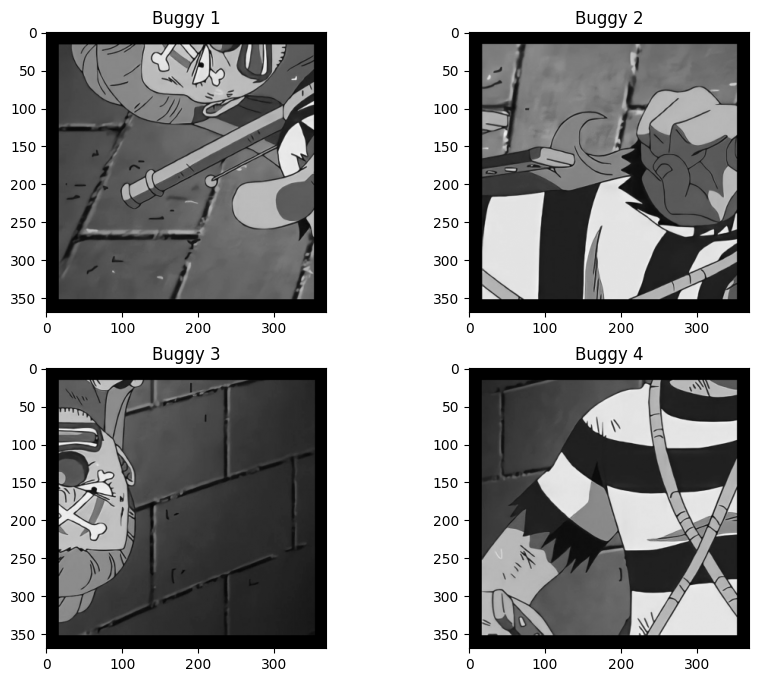

In [3]:
#GRAYSCALE
citra1_gray = cv2.cvtColor(citra1, cv2.COLOR_BGR2GRAY)
citra2_gray = cv2.cvtColor(citra2, cv2.COLOR_BGR2GRAY)
citra3_gray = cv2.cvtColor(citra3, cv2.COLOR_BGR2GRAY)
citra4_gray = cv2.cvtColor(citra4, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(citra1_gray, cmap='gray')
plt.title('Buggy 1')

plt.subplot(2, 2, 2)
plt.imshow(citra2_gray, cmap='gray')
plt.title('Buggy 2')

plt.subplot(2, 2, 3)
plt.imshow(citra3_gray, cmap='gray')
plt.title('Buggy 3')

plt.subplot(2, 2, 4)
plt.imshow(citra4_gray, cmap='gray')
plt.title('Buggy 4')

plt.show()

In [4]:
def rotasi(img, sudut):
    rad = np.radians(sudut)
    cos = np.cos(rad)
    sin = np.sin(rad)

    hasil = np.zeros_like(img)
    h, w = img.shape[:2]
    cx, cy = w / 2, h / 2

    for i in range(h):
        for j in range(w):
            x = j - cx
            y = i - cy
            
            new_x = int(x * cos + y * sin + cx)
            new_y = int(-x * sin + y * cos + cy)
            
            if 0 <= new_x < w and 0 <= new_y < h:
                hasil[i, j] = img[new_y, new_x]
                
    return hasil

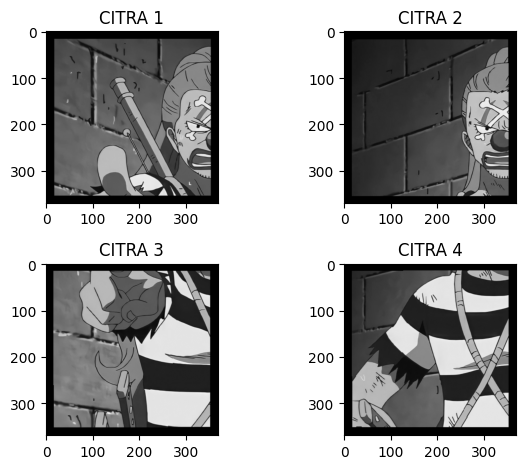

In [5]:
citraR1 = rotasi(citra1_gray, 90)
citraR2 = rotasi(citra3_gray, 180)
citraR3 = rotasi(citra2_gray, 270)
citraR4 = rotasi(citra4_gray, 360)


plt.subplot(2, 2, 1)
plt.imshow(citraR1, cmap='gray')
plt.title("CITRA 1")

plt.subplot(2, 2, 2)
plt.imshow(citraR2, cmap='gray')
plt.title("CITRA 2")

plt.subplot(2, 2, 3)
plt.imshow(citraR3, cmap='gray')
plt.title("CITRA 3")

plt.subplot(2, 2, 4)
plt.imshow(citraR4, cmap='gray')
plt.title("CITRA 4")
plt.tight_layout()
plt.show()

In [6]:
def flip(img, mode='Y'):
    h, w = img.shape[:2]
    hasil = np.zeros_like(img)
    
    for i in range(h):
        for j in range(w):
            if mode == 'Y': # Horizontal Flip
                new_x = (w - 1) - j
                new_y = i
            elif mode == 'X': # Vertical Flip
                new_x = j
                new_y = (h - 1) - i
            
            hasil[i, j] = img[new_y, new_x]
            
    return hasil

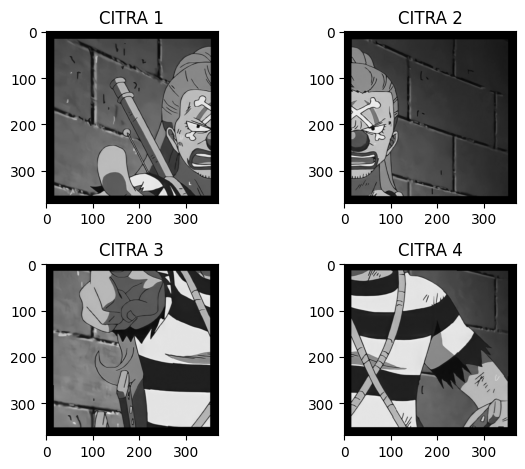

In [7]:
citra2V = flip(citraR2, mode='Y')
citra4V = flip(citraR4, mode='Y')

plt.subplot(2, 2, 1)
plt.imshow(citraR1, cmap='gray')
plt.title("CITRA 1")

plt.subplot(2, 2, 2)
plt.imshow(citra2V, cmap='gray')
plt.title("CITRA 2")

plt.subplot(2, 2, 3)
plt.imshow(citraR3, cmap='gray')
plt.title("CITRA 3")

plt.subplot(2, 2, 4)
plt.imshow(citra4V, cmap='gray')
plt.title("CITRA 4")
plt.tight_layout()
plt.show()


In [8]:
def slicing(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape[:2]
    dilated = np.zeros((h * 2, w * 2), dtype=image.dtype)

    dilated[0::2, 0::2] = image 
    dilated[1::2, 0::2] = image 
    dilated[0::2, 1::2] = image
    dilated[1::2, 1::2] = image 
    
    h2, w2 = dilated.shape[:2]
    sy, ey = max(0, p1), min(h2, h2 - p2)
    sx, ex = max(0, p3), min(w2, w2 - p4)
    
    return dilated[sy:ey, sx:ex]

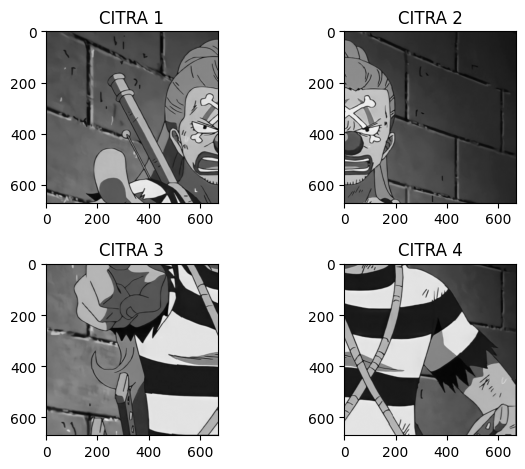

In [9]:
citra1S = slicing(citraR1, p1=34, p2=34, p3=34, p4=34)
citra2S = slicing(citra2V, p1=34, p2=34, p3=34, p4=34)
citra3S = slicing(citraR3, p1=34, p2=34, p3=34, p4=34)
citra4S = slicing(citra4V, p1=34, p2=34, p3=34, p4=34)

plt.subplot(2, 2, 1)
plt.imshow(citra1S, cmap='gray')
plt.title("CITRA 1")

plt.subplot(2, 2, 2)
plt.imshow(citra2S, cmap='gray')
plt.title("CITRA 2")

plt.subplot(2, 2, 3)
plt.imshow(citra3S, cmap='gray')
plt.title("CITRA 3")

plt.subplot(2, 2, 4)
plt.imshow(citra4S, cmap='gray')
plt.title("CITRA 4")
plt.tight_layout()
plt.show()

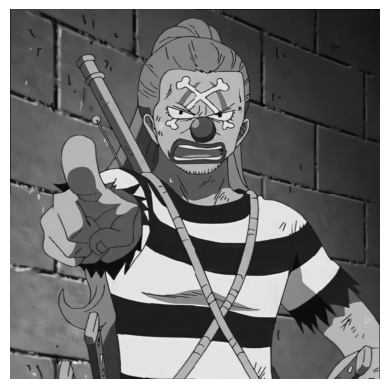

In [10]:
def merge(c1, c2, c3, c4):
    h, w = c1.shape
    hasil = np.zeros((h * 2, w * 2), dtype=c1.dtype)

    hasil[0:h, 0:w] = c1       
    hasil[0:h, w:w*2] = c2     
    hasil[h:h*2, 0:w] = c3    
    hasil[h:h*2, w:w*2] = c4   
    
    return hasil
hasil = merge(citra1S, citra2S, citra3S, citra4S)
plt.imshow(hasil, cmap='gray')
plt.axis('off')
plt.show()

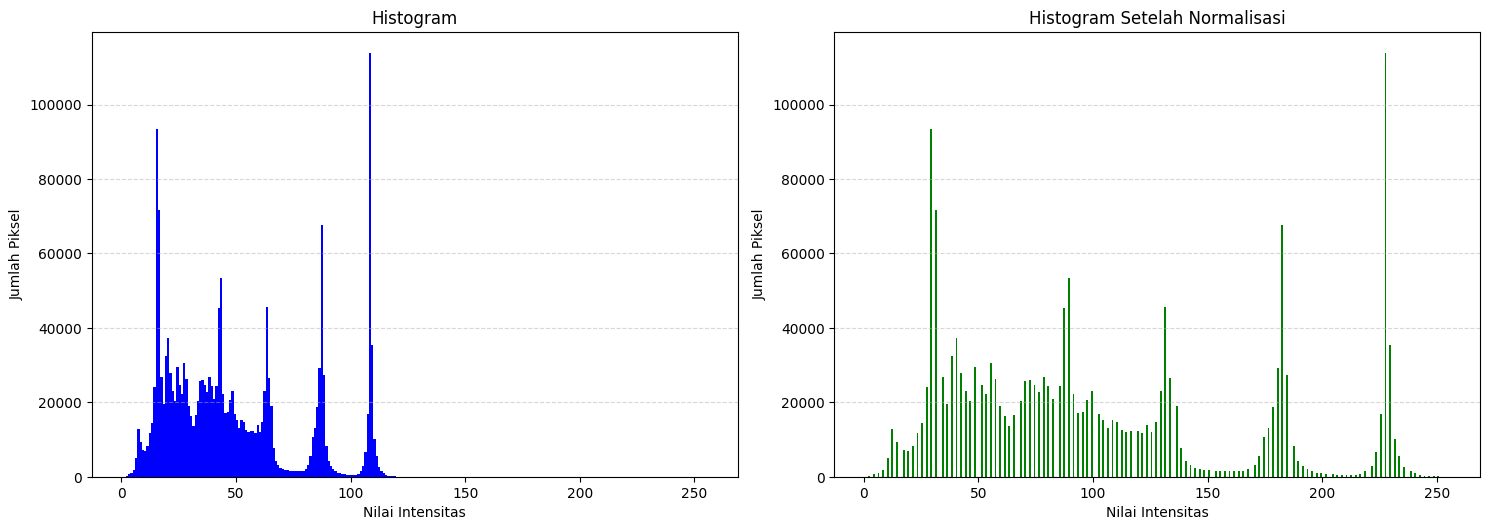

In [11]:
if np.max(hasil) <= 1.0:
    citra_dibagi = ((hasil * 255) // 2).astype(np.uint8)
else:
    citra_dibagi = (hasil // 2).astype(np.uint8)

def Normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    
    if max_val == min_val:
        return image

    normalisasi = (image - min_val) / (max_val - min_val) * 255
    return normalisasi.astype(np.uint8)

citra_normal = Normalisasi(citra_dibagi)
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 3)
plt.hist(citra_dibagi.ravel(), bins=256, range=[0, 256], color='blue')
plt.title("Histogram")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(2, 2, 4)
plt.hist(citra_normal.ravel(), bins=256, range=[0, 256], color='green', rwidth=0.8)
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

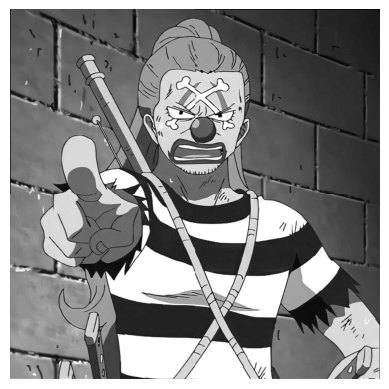

In [12]:
def konvolusi(image):
    h, w = image.shape
    
    kernel = np.array([ 
            [-1/10, -1/10, -1/10, -1/10], 
            [-1/10,  6/10,  6/10, -1/10], 
            [-1/10,  6/10,  6/10, -1/10], 
            [-1/10, -1/10, -1/10, -1/10] 
            ]) 

    kh, kw = kernel.shape
       
    pad = 2
    padded_img = np.zeros((h + pad*2, w + pad*2), dtype=float)
    padded_img[pad:pad+h, pad:pad+w] = image
    
    output = np.zeros((h, w), dtype=float)

    for i in range(kh):
        for j in range(kw):
            output += padded_img[i:i+h, j:j+w] * kernel[i, j]

    output_clipped = np.clip(output, 0, 255)

    return output_clipped.astype(np.uint8)

hasil_konvolusi = konvolusi(citra_normal)
plt.imshow(hasil_konvolusi, cmap='gray')
plt.axis('off')
plt.show()